In [1]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt 
import os 


class GoalDataset(Dataset):
    def __init__(self, dataframe,transform=None):
        self.data = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx, 0]
        label = int(self.data.iloc[idx, 1])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [31]:
print(torch.cuda.is_available())

False


In [ ]:
import os
import pandas as pd

def create_dataframe_shot_only(dataset_root):
    rows = []

    for shot_folder in os.listdir(dataset_root):
        folder_path = os.path.join(dataset_root, shot_folder)
        if not os.path.isdir(folder_path):
            continue

        label_path = os.path.join(folder_path, "label.txt")
        if not os.path.exists(label_path):
            print(f"Etiqueta no encontrada en {folder_path}")
            continue
        with open(label_path, "r") as f:
            label = int(f.read().strip())

        shot_img_path = os.path.join(folder_path, "frame_shot.jpg")
        if os.path.exists(shot_img_path):
            rows.append([shot_img_path, label])
        else:
            print(f"Frame shot no trobat en {folder_path}")

    df = pd.DataFrame(rows, columns=["image_path", "label"])
    return df


dataset_path= "./Dataset_final/Frames_Bons_Definitius"
df = create_dataframe_shot_only(dataset_path)

Data=GoalDataset(df)

In [ ]:
image_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

In [26]:
def get_dataloaders(df, batch_size=32, split_ratio=0.8):
    dataset = GoalDataset(df, transform=image_transforms['train'])

    train_size = int(split_ratio * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    # Replace transforms for validation set
    val_dataset.dataset.transform = image_transforms['val']

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader


In [ ]:


class CoordConvLayer(nn.Module):
    def __init__(self, with_r=False):
        super(CoordConvLayer, self).__init__()
        self.with_r = with_r

    def forward(self, x):
        """
        Añade canales coordenados a la imagen.
        x: batch x channels x height x width
        retorna: batch x (channels + 2 or 3) x height x width
        """
        batch_size, _, height, width = x.size()
        device = x.device

        xx_channel = torch.linspace(-1, 1, steps=width, device=device).repeat(1, height, 1)
        yy_channel = torch.linspace(-1, 1, steps=height, device=device).repeat(1, width, 1).transpose(1, 2)

        xx_channel = xx_channel.expand(batch_size, 1, height, width)
        yy_channel = yy_channel.expand(batch_size, 1, height, width)

        ret = torch.cat([x, xx_channel, yy_channel], dim=1)

        if self.with_r:
            rr = torch.sqrt(xx_channel ** 2 + yy_channel ** 2)
            ret = torch.cat([ret, rr], dim=1)

        return ret

class ModelCNN(nn.Module):
    def __init__(self):
        super(ModelCNN, self).__init__()
        self.coordconv = CoordConvLayer()  # Añadimos el módulo que añade coordenadas
        self.conv1 = nn.Conv2d(5, 16, 3, padding=1)  # Cambiamos canales de entrada de 3 a 5
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.coordconv(x)                       # Agrega los canales coordenados
        x = self.pool(F.relu(self.conv1(x)))       # 112x112
        x = self.pool(F.relu(self.conv2(x)))       # 56x56
        x = x.view(-1, 32 * 56 * 56)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x


In [33]:
def train(epoch, criterion, model, optimizer, loader,device):

    total_loss = 0.0

    model.train()

    for batch_idx, (data, target) in enumerate(loader):

        optimizer.zero_grad()

        data, target = data.to(device), target.to(device)

        output = model(data)
        output = output.view(-1)  
        loss = criterion(output, target.float())
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(loader.dataset),
                100. * batch_idx / len(loader), loss.item()))


        total_loss += loss.item()  
    return total_loss / len(loader.dataset)


In [ ]:

def validate(criterion, model, loader, device):
    val_loss = 0
    correct = 0

    model.eval()
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data).view(-1)  
            loss = criterion(output, target.float())
            val_loss += loss.item()

            pred = (output >= 0.5).long()  # predicción binaria
            correct += pred.eq(target).sum().item()

    val_loss /= len(loader.dataset)
    accuracy = 100. * correct / len(loader.dataset)
    print(f'\nTest set: Average loss: {val_loss:.4f}, Accuracy: {correct}/{len(loader.dataset)} ({accuracy:.0f}%)\n')

    return val_loss



In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
torch.backends.cudnn.benchmark = True
learning_rate = 1e-4
lambda_l2 = 1e-5
momentum = 0.5
epoch=10
torch.manual_seed(0)
model=ModelCNN()
model.to(device)
train_loader, val_loader = get_dataloaders(df, batch_size=32)
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=lambda_l2)

cpu


Train Epoch: 0 [0/1134 (0%)]	Loss: 0.717015

Test set: Average loss: 0.0141, Accuracy: 241/284 (85%)

Train Epoch: 1 [0/1134 (0%)]	Loss: 0.372223

Test set: Average loss: 0.0134, Accuracy: 241/284 (85%)

Train Epoch: 2 [0/1134 (0%)]	Loss: 0.324085

Test set: Average loss: 0.0134, Accuracy: 241/284 (85%)

Train Epoch: 3 [0/1134 (0%)]	Loss: 0.305122

Test set: Average loss: 0.0146, Accuracy: 241/284 (85%)

Train Epoch: 4 [0/1134 (0%)]	Loss: 0.541316

Test set: Average loss: 0.0135, Accuracy: 241/284 (85%)

Train Epoch: 5 [0/1134 (0%)]	Loss: 0.483919

Test set: Average loss: 0.0137, Accuracy: 241/284 (85%)

Train Epoch: 6 [0/1134 (0%)]	Loss: 0.215724

Test set: Average loss: 0.0143, Accuracy: 241/284 (85%)

Train Epoch: 7 [0/1134 (0%)]	Loss: 0.358174

Test set: Average loss: 0.0139, Accuracy: 241/284 (85%)

Train Epoch: 8 [0/1134 (0%)]	Loss: 0.396410

Test set: Average loss: 0.0144, Accuracy: 240/284 (85%)

Train Epoch: 9 [0/1134 (0%)]	Loss: 0.312737

Test set: Average loss: 0.0142, Accur

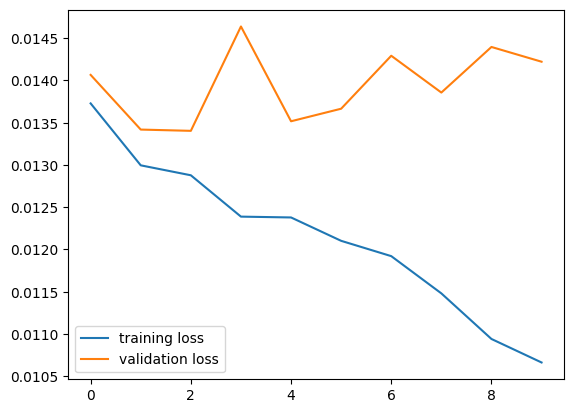

In [36]:
losses= {"train":[], "validate":[] }
losses = {"train": [], "val": []}

for epoch in range(10):

    train_loss = train(epoch, criterion, model, optimizer, train_loader, device)
    val_loss = validate(criterion, model, val_loader, device)
    losses["train"].append(train_loss)
    losses["val"].append(val_loss)

plt.plot(losses["train"], label="training loss")
plt.plot(losses["val"], label="validation loss")

plt.legend()
plt.pause(0.000001)
plt.show()
